# Data Analysis for Option 1 Results

In [779]:
import pandas as pd
import numpy 
import os

endpoint = "chr-kidney"
increment = 5

full_df = pd.read_csv(f"../references/full_print_results/{endpoint}/big_results_percentages{increment}_neighborhood2-13.csv")
full_df = full_df.drop(columns = {"Unnamed: 0"})

# if not os.path.exists(f"..references/full_print_results/{endpoint}/full_scatters"):
#     for folder in ["full_scatters", "Highlights", "multi-scores", "reg1_graphs", "reg2_graphs", "reg3_graphs", "strat_graphs"]:
#         os.mkdir(f"../references/full_print_results/{endpoint}/{folder}")

In [780]:
full_df[['param_hybrid_weights', 'param_n_neighbors','split0_test_roc_auc',
       'split1_test_roc_auc', 'split2_test_roc_auc', 'mean_test_accuracy', 'std_test_accuracy', 'mean_test_roc_auc', 'mean_test_recall']].sort_values("mean_test_roc_auc", ascending = False).head(10)

,param_hybrid_weights,param_n_neighbors,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,mean_test_accuracy,std_test_accuracy,mean_test_roc_auc,mean_test_recall
88135,"[25, 25, 45, 5, 0]",9,0.587160,0.656463,0.595663,0.690123,0.029836,0.642548,0.917662
104974,"[35, 35, 25, 0, 5]",12,0.577381,0.625000,0.595663,0.679802,0.037312,0.641419,0.910649
88795,"[25, 30, 40, 5, 0]",9,0.587160,0.643707,0.617347,0.682331,0.039573,0.637789,0.910519
66981,"[15, 40, 10, 5, 30]",11,0.637330,0.596088,0.564626,0.687526,0.026910,0.636752,0.917662
70571,"[20, 0, 35, 5, 40]",13,0.582058,0.611820,0.619898,0.692755,0.030919,0.636411,0.932013
111070,"[40, 50, 5, 5, 0]",12,0.592262,0.613946,0.590561,0.690157,0.018205,0.635572,0.921364
71939,"[20, 5, 20, 10, 45]",13,0.586310,0.614371,0.630952,0.690157,0.028349,0.635402,0.935584
66321,"[15, 35, 15, 5, 30]",11,0.622024,0.567602,0.603316,0.684928,0.024742,0.635247,0.914026
83013,"[25, 5, 10, 10, 50]",11,0.572704,0.602041,0.621599,0.677170,0.029182,0.635113,0.910584
97449,"[30, 30, 30, 0, 10]",11,0.582908,0.596939,0.587585,0.692789,0.030636,0.635025,0.935714


In [555]:
#Weights saved as a string for the CSV, so we will fix this (if integer weights)
# df = full_df[["param_hybrid_weights", "mean_test_accuracy","mean_test_precision","mean_test_recall", "mean_test_roc_auc"]].sort_values("mean_test_roc_auc", ascending = False) 
# df["param_hybrid_weights"] = [ [int(df["param_hybrid_weights"][i][1]), int(df["param_hybrid_weights"][i][4]), int(df["param_hybrid_weights"][i][7]), int(df["param_hybrid_weights"][i][10]), int(df["param_hybrid_weights"][i][13])] for i in range(0, len(df["param_hybrid_weights"]))]
# df.head()

In [782]:
#If percentage weights, we will need this version:
#.loc[full_df["param_n_neighbors"]==4]
df = full_df[["param_hybrid_weights", "param_n_neighbors", "mean_test_accuracy","mean_test_precision","mean_test_recall", "mean_test_roc_auc"]].sort_values("mean_test_roc_auc", ascending = False) 
new_weights = []
for i in df["param_hybrid_weights"]:
    number_list = i.split(",")
    first = number_list[0][1:]
    last = number_list[-1][:-1]
    new_weights.append([int(first), int(number_list[1]), int(number_list[2]), int(number_list[3]), int(last)])
df["param_hybrid_weights"] = new_weights
df = df.reset_index()
df = df.drop(columns={"index"})

In [783]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [df["param_hybrid_weights"][i][1] for i in range(0,len(df["param_hybrid_weights"]))]
toxprint_weight = [df["param_hybrid_weights"][i][0] for i in range(0,len(df["param_hybrid_weights"]))]
torsion_weight = [df["param_hybrid_weights"][i][2] for i in range(0,len(df["param_hybrid_weights"]))]
toxcast_weight = [df["param_hybrid_weights"][i][3] for i in range(0,len(df["param_hybrid_weights"]))]
aims_weight = [df["param_hybrid_weights"][i][4] for i in range(0,len(df["param_hybrid_weights"]))]

df["morgan"] = [morgan_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(morgan_weight))]
df["toxprint"] = [toxprint_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxprint_weight))]
df["torsion"] = [torsion_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(torsion_weight))]
df["toxcast"] = [toxcast_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxcast_weight))]
df["aims"] = [aims_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(aims_weight))]


In [784]:
#By changing the weight tested, we can see here which neighborhood size is optimal for each fingerprint
#Note that for mgr-lung, where clearly a  neighborhood size of 4 or 5 is best, each individual fingerprint
#(except torsion) still does best with a very large neighborhood. This may indicate that hybrid fingerprints 
#are particularly important on small data sets.
scan_df = df.loc[[100 in df['param_hybrid_weights'][i] for i in range(0,len(df))]]
scan_df.loc[scan_df["aims"]==1]

,param_hybrid_weights,param_n_neighbors,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
110355,"[0, 0, 0, 0, 100]",9,0.690191,0.719379,0.939221,0.544523,0.0,0.0,0.0,0.0,1.0
114319,"[0, 0, 0, 0, 100]",11,0.695386,0.718103,0.953571,0.538182,0.0,0.0,0.0,0.0,1.0
115669,"[0, 0, 0, 0, 100]",10,0.679802,0.717276,0.921364,0.535487,0.0,0.0,0.0,0.0,1.0
118198,"[0, 0, 0, 0, 100]",7,0.669310,0.718592,0.896039,0.530291,0.0,0.0,0.0,0.0,1.0
119778,"[0, 0, 0, 0, 100]",13,0.695386,0.716711,0.957143,0.526419,0.0,0.0,0.0,0.0,1.0
120939,"[0, 0, 0, 0, 100]",6,0.643336,0.717322,0.838831,0.523167,0.0,0.0,0.0,0.0,1.0
120957,"[0, 0, 0, 0, 100]",12,0.682365,0.715078,0.932078,0.523123,0.0,0.0,0.0,0.0,1.0
122846,"[0, 0, 0, 0, 100]",8,0.664149,0.717991,0.885325,0.516742,0.0,0.0,0.0,0.0,1.0
125228,"[0, 0, 0, 0, 100]",5,0.661517,0.711389,0.896039,0.504765,0.0,0.0,0.0,0.0,1.0
127302,"[0, 0, 0, 0, 100]",3,0.645967,0.709525,0.863961,0.474244,0.0,0.0,0.0,0.0,1.0


In [742]:
df = df.sort_values("mean_test_accuracy", ascending = False).drop(columns = {"param_hybrid_weights"})
df.head()

,param_n_neighbors,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
51864,11,0.731681,0.741599,0.967727,0.587675,0.00,0.0,0.75,0.25,0.00
73316,13,0.726487,0.733260,0.978442,0.576782,0.05,0.0,0.75,0.15,0.05
83203,13,0.723958,0.731496,0.978571,0.570783,0.30,0.0,0.70,0.00,0.00
87443,11,0.723923,0.735352,0.967792,0.567895,0.05,0.0,0.95,0.00,0.00
11150,13,0.723923,0.731331,0.978442,0.609103,0.00,0.0,0.45,0.50,0.05


## Top/Bottom DataFrame Creation
 There are many, many results for this data set, so let's look only at the best and worst in each category to examine patterns as well. 

In [734]:
accuracy_df1 = df.sort_values("mean_test_accuracy").iloc[0:10, :]
accuracy_df2 = df.sort_values("mean_test_accuracy").iloc[-10:, :]
accuracy_df3 = df.sort_values("mean_test_accuracy").iloc[round(len(df)/2-5):round(len(df)/2+5), :]
accuracy_df = pd.concat([accuracy_df1, accuracy_df2, accuracy_df3]).sort_values("mean_test_accuracy", ascending = False)
accuracy_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
51864,0.731681,0.741599,0.967727,0.587675,0.00,0.00,0.75,0.25,0.00
73316,0.726487,0.733260,0.978442,0.576782,0.05,0.00,0.75,0.15,0.05
83203,0.723958,0.731496,0.978571,0.570783,0.30,0.00,0.70,0.00,0.00
87443,0.723923,0.735352,0.967792,0.567895,0.05,0.00,0.95,0.00,0.00
11150,0.723923,0.731331,0.978442,0.609103,0.00,0.00,0.45,0.50,0.05
40177,0.723889,0.732556,0.974870,0.593175,0.00,0.00,0.80,0.20,0.00
96753,0.721360,0.732038,0.971364,0.560483,0.25,0.05,0.70,0.00,0.00
79916,0.721360,0.729436,0.978571,0.572923,0.20,0.05,0.75,0.00,0.00
79250,0.721360,0.729420,0.978571,0.573338,0.15,0.05,0.80,0.00,0.00
91968,0.721360,0.730812,0.975000,0.564538,0.25,0.00,0.75,0.00,0.00


In [560]:
precision_df1 = df.sort_values("mean_test_precision").iloc[0:10, :]
precision_df2 = df.sort_values("mean_test_precision").iloc[-10:, :]
precision_df3 = df.sort_values("mean_test_precision").iloc[round(len(df)/2-5):round(len(df)/2+5), :]
precision_df = pd.concat([precision_df1, precision_df2, precision_df3]).sort_values("mean_test_precision", ascending = False)
precision_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
1508,0.716165,0.734968,0.953571,0.612240,0.95,0.00,0.05,0.00,0.00
4071,0.718729,0.733625,0.960519,0.603166,0.05,0.00,0.10,0.80,0.05
9869,0.726487,0.733260,0.978442,0.576782,0.05,0.00,0.75,0.15,0.05
4353,0.721326,0.733163,0.967662,0.602304,0.00,0.00,0.15,0.85,0.00
621,0.716097,0.733080,0.957013,0.617490,0.00,0.00,0.65,0.30,0.05
3012,0.713568,0.732964,0.953571,0.606700,0.75,0.05,0.20,0.00,0.00
5772,0.713568,0.732750,0.953571,0.597657,0.70,0.05,0.25,0.00,0.00
3004,0.718694,0.732633,0.964156,0.606737,0.20,0.10,0.05,0.60,0.05
7807,0.718729,0.732559,0.964156,0.589926,0.20,0.00,0.65,0.15,0.00
7001,0.723889,0.732556,0.974870,0.593175,0.00,0.00,0.80,0.20,0.00


In [561]:
recall_df1 = df.sort_values("mean_test_recall").iloc[0:10, :]
recall_df2 = df.sort_values("mean_test_recall").iloc[-10:, :]
recall_df3 = df.sort_values("mean_test_recall").iloc[round(len(df)/2-5):round(len(df)/2+5), :]
recall_df = pd.concat([recall_df1, recall_df2, recall_df3]).sort_values("mean_test_recall", ascending = False)
recall_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
10498,0.716165,0.724156,0.982143,0.562767,0.05,0.05,0.90,0.00,0.00
6451,0.721360,0.728052,0.982078,0.595176,0.15,0.25,0.60,0.00,0.00
285,0.718729,0.726185,0.982078,0.620832,0.00,0.05,0.45,0.45,0.05
670,0.718729,0.726051,0.982013,0.617019,0.00,0.10,0.45,0.45,0.00
10087,0.721360,0.729420,0.978571,0.573338,0.15,0.05,0.80,0.00,0.00
10107,0.721360,0.729436,0.978571,0.572923,0.20,0.05,0.75,0.00,0.00
10316,0.718763,0.727329,0.978571,0.568884,0.10,0.00,0.90,0.00,0.00
10489,0.718763,0.727474,0.978571,0.563388,0.10,0.05,0.85,0.00,0.00
10222,0.723958,0.731496,0.978571,0.570783,0.30,0.00,0.70,0.00,0.00
10447,0.716131,0.725366,0.978506,0.564941,0.00,0.00,1.00,0.00,0.00


In [735]:
roc_df1 = df.sort_values("mean_test_roc_auc").iloc[0:10, :]
roc_df2 = df.sort_values("mean_test_roc_auc").iloc[-10:, :]
roc_df3 = df.sort_values("mean_test_roc_auc").iloc[round(len(df)/2-5):round(len(df)/2+5), :]
roc_df = pd.concat([roc_df1, roc_df2, roc_df3]).sort_values("mean_test_roc_auc", ascending=False)
roc_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
0,0.690123,0.727145,0.917662,0.642548,0.25,0.25,0.45,0.05,0.00
1,0.679802,0.721457,0.910649,0.641419,0.35,0.35,0.25,0.00,0.05
2,0.682331,0.723349,0.910519,0.637789,0.30,0.25,0.40,0.05,0.00
3,0.687526,0.725782,0.917662,0.636752,0.40,0.15,0.10,0.05,0.30
4,0.692755,0.724050,0.932013,0.636411,0.00,0.20,0.35,0.05,0.40
5,0.690157,0.726266,0.921364,0.635572,0.50,0.40,0.05,0.05,0.00
6,0.690157,0.720536,0.935584,0.635402,0.05,0.20,0.20,0.10,0.45
7,0.684928,0.725025,0.914026,0.635247,0.35,0.15,0.15,0.05,0.30
8,0.677170,0.719702,0.910584,0.635113,0.05,0.25,0.10,0.10,0.50
9,0.692789,0.722772,0.935714,0.635025,0.30,0.30,0.30,0.00,0.10


## Graph Generation

In [691]:
#Master test variable settings, for generating graphs with given settings from all cells
test_variables = {"x":"toxcast", "y":"accuracy", "c":"toxcast"}

### Stratified Graphs

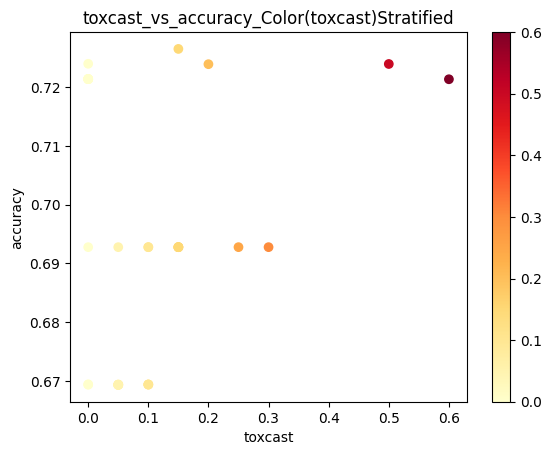

In [692]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice

#Accuracy strata
test_variables["y"] = "accuracy"
plt.scatter(x = accuracy_df[test_variables["x"]], y= accuracy_df["mean_test_accuracy"], c= accuracy_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

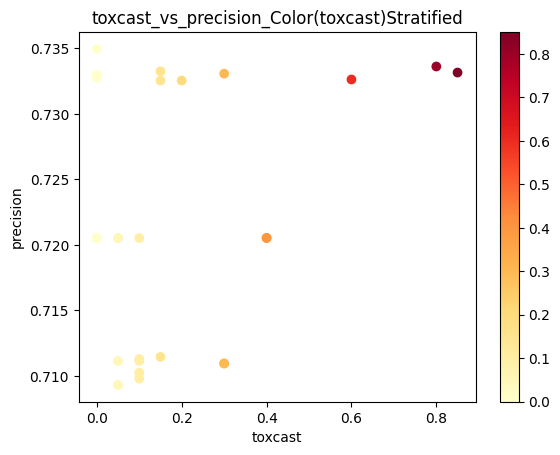

In [693]:
#Precision strata
test_variables["y"] = "precision"
plt.scatter(x = precision_df[test_variables["x"]], y= precision_df["mean_test_precision"], c= precision_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

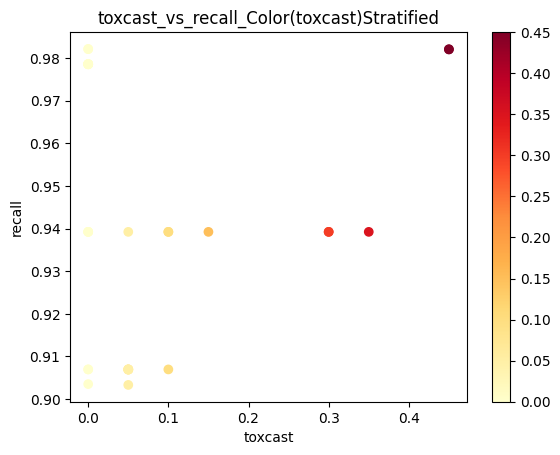

In [694]:
#Recall strata
test_variables["y"] = "recall"
plt.scatter(x = recall_df[test_variables["x"]], y= recall_df["mean_test_recall"], c= recall_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

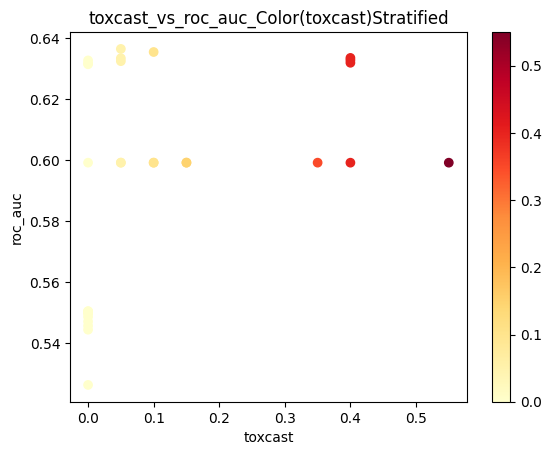

In [695]:
#ROC strata
test_variables["y"] = "roc_auc"
plt.scatter(x = roc_df[test_variables["x"]], y= roc_df["mean_test_roc_auc"], c= roc_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

### Full data graph

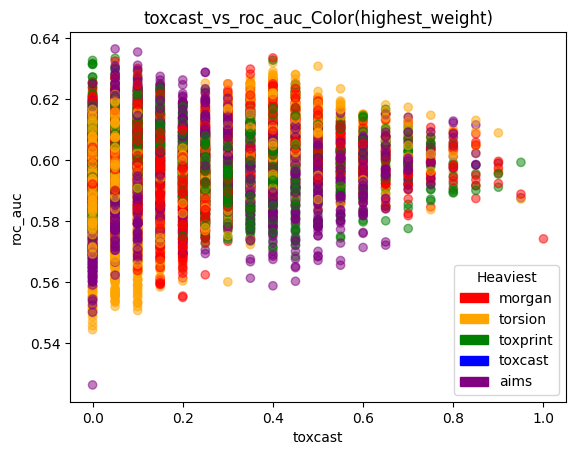

In [696]:
#Full data set comparisons
import matplotlib.patches as mpatches

df = df.reset_index(drop=True)
test_variables["y"] = "roc_auc"

color_map = {"morgan":"red", "torsion":"orange", "toxprint":"green", "toxcast":"blue", "aims":"purple"}
color_list = []
for i in range(0,len(df)):
    measures = {"morgan":df["morgan"][i], "torsion":df["torsion"][i], "toxprint":df["toxprint"][i], "toxcast":df["toxcast"][i], "aims":df["aims"][i]}
    measures.pop(test_variables['x'])
    max_spot = list(measures.values()).index(max(measures.values()))
    color_list.append(color_map[list(measures.keys())[max_spot]])

plt.scatter(x = df[test_variables["x"]], y= df[f"mean_test_{test_variables["y"]}"], c= color_list, alpha=0.5)
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
legend = [mpatches.Patch(color = value, label = key) for key, value in color_map.items()]
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color(highest_weight)"
plt.title(title)
plt.legend(title = "Heaviest", handles = legend)
plt.savefig(f"../references/full_print_results/{endpoint}/full_scatters/{title}_scatter.png")
plt.show()

### Regression-Ready Graphs 
These first two were visually informative when we worked with the four_print_results, but became overloaded in some areas and underloaded in others when the many extra tests of the full results were introduced. A reworked attempt can be seen below. 

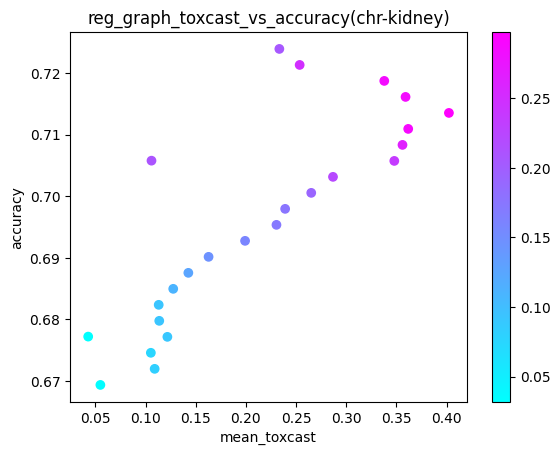

In [712]:
from numpy import arange
from statistics import mean

#Plot average weight of a given fingerprint against the average score in a given neighborhood, this could
#allow for regression analysis of the relation between fingerprint weight and scores
score = "accuracy"
weight = test_variables["x"]

averages = {score:[], weight: [], "size":[], "std": [] }
minimum = min(df[f"mean_test_{score}"])
maximum = max(df[f"mean_test_{score}"])
data_range = maximum -minimum

for i in arange(minimum, maximum, data_range/40):
    selection = df.loc[(df[f"mean_test_{score}"] < i+data_range/80) & (df[f"mean_test_{score}"] >= i-data_range/80)]
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["size"].append(len(selection))
        averages["std"].append(numpy.std(selection_weight))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["std"], cmap = "cool", )
plt.colorbar()
plt.xlabel("mean_"+weight)
plt.ylabel(score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/reg1_graphs/{title}.png")
plt.show()

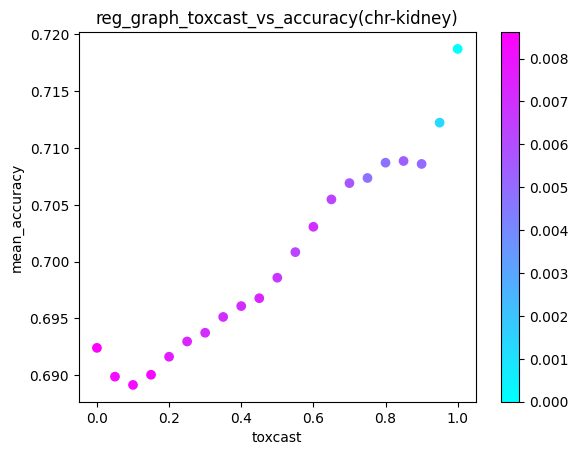

In [713]:
#For each possible weight of a fingerprint, plot average performance by score

averages = {score:[], weight: [], "size":[], "std":[] }

#For int weights: arange step = 0.03. For percent weights: arange step = 0.1

for i in arange(0,1.1, 0.05):
    selection = df.loc[(df[weight] < i+0.025) & (df[weight] >= i-0.025)]
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["size"].append(len(selection))
        averages["std"].append(numpy.std(selection_score))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["std"], cmap = "cool",)
plt.colorbar()
plt.xlabel(weight)
plt.ylabel("mean_"+score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/reg2_graphs/{title}.png")
plt.show()

#### Reworked Reg_graphs (int weights only)

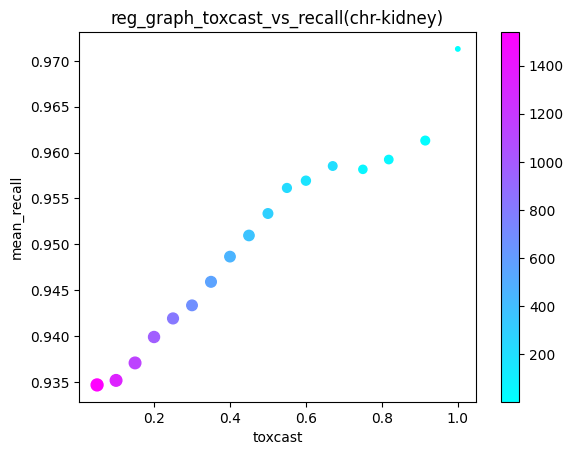

In [714]:
#For each possible weight of a fingerprint, plot average performance by score
import numpy
from numpy import exp
score = "recall"
weight = test_variables["x"]

averages = {score:[], weight: [], "std": [], "size":[]}

next_start = 0
for i in arange(0,1, 0.01):
    selection = df.loc[(df[weight]>next_start) & (df[weight]< (next_start + exp(-10)*exp(10*i)))]
    next_start = (next_start + exp(-10)*exp(10*i))
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["std"].append(numpy.std(selection_score))
        averages["size"].append(len(selection))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["size"], cmap = "cool", s = 5000*avg_df["std"]+10)
plt.colorbar()
plt.xlabel(weight)
plt.ylabel("mean_"+score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
# plt.savefig(f"../references/full_print_results/{endpoint}/reg3_graphs/{title}.png")
plt.show()

### Multi-Score Graph

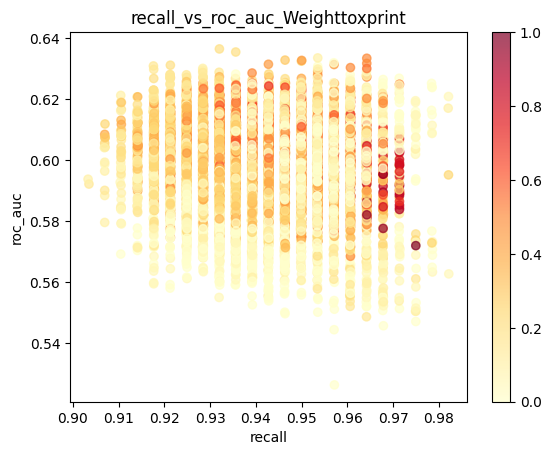

In [715]:
#Multi-scores
multi_variables = {"x":"recall", "y":"roc_auc", "c":"toxprint"}
plt.scatter(x = df[f"mean_test_{multi_variables["x"]}"], y=df[f"mean_test_{multi_variables["y"]}"], c= df[multi_variables["c"]], cmap = "YlOrRd", alpha = 0.7)
plt.colorbar()
title = f"{multi_variables["x"]}_vs_{multi_variables["y"]}_Weight{multi_variables['c']}"
plt.title(title)
plt.xlabel(multi_variables["x"])
plt.ylabel(multi_variables["y"])
plt.savefig(f"../references/full_print_results/{endpoint}/multi-scores/{title}_scatter.png")
plt.show()

# Data Analysis for Long-Form Results

In [ ]:
import pandas as pd

score_df = pd.read_csv("../references/tp_tor_mor/prelim_results+tc_df.csv")
score_df["weights"] = [ [int(score_df["weights"][i][1]), int(score_df["weights"][i][4]), int(score_df["weights"][i][7]), int(score_df["weights"][i][10])] for i in range(0, len(score_df["weights"]))]
score_df.head()

In [ ]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [score_df["weights"][i][1] for i in range(0,len(score_df["weights"]))]
toxprint_weight = [score_df["weights"][i][0] for i in range(0,len(score_df["weights"]))]
torsion_weight = [score_df["weights"][i][2] for i in range(0,len(score_df["weights"]))]
toxcast_weight = [score_df["weights"][i][3] for i in range(0,len(score_df["weights"]))]

score_df["morgan"] = [morgan_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(morgan_weight))]
score_df["toxprint"] = [toxprint_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxprint_weight))]
score_df["torsion"] = [torsion_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(torsion_weight))]
score_df["toxcast"] = [toxcast_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxcast_weight))]

In [ ]:
#Check the DataFrame
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177,0.0,0.0,0.000000,1.000000
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365,0.0,0.0,1.000000,0.000000
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177,0.0,0.0,0.500000,0.500000
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464,0.0,0.0,0.333333,0.666667
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414,0.0,0.0,0.666667,0.333333


In [ ]:
#Obtain best combination for accuracy
score_df.loc[score_df["accuracy"]==max(score_df["accuracy"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
22,"[1, 0, 1, 0]",344,16,90,18,0.769231,0.792627,0.950276,0.0,0.5,0.5,0.0


In [ ]:
#Obtain best combination for precision
score_df.loc[score_df["precision"]==max(score_df["precision"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
50,"[2, 0, 2, 1]",341,17,89,21,0.764957,0.793023,0.941989,0.0,0.4,0.4,0.2


In [ ]:
#Obtain best combination for recall
score_df.loc[score_df["recall"]==max(score_df["recall"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
19,"[1, 0, 0, 0]",345,11,95,17,0.760684,0.784091,0.953039,0.0,1.0,0.0,0.0


In [ ]:
#Obtain best combination for not getting false positives
score_df.loc[score_df["FP"]==min(score_df["FP"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.0,0.0,1.0
27,"[1, 0, 2, 2]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.2,0.4,0.4


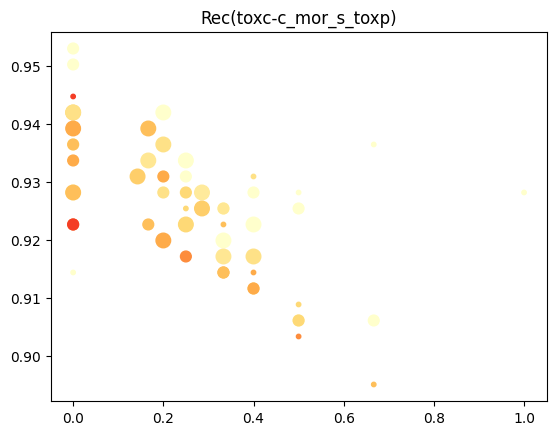

In [ ]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice
plt.scatter(x = score_df["toxcast"], y= score_df["recall"], c= score_df["morgan"], cmap = "YlOrRd", s = [i*50+10 for i in toxprint_weight])
title = "Rec(toxc-c_mor_s_toxp)"
plt.title(title)
# plt.savefig(f"../references/tp_tor_mor/91test{title}percents_scatter.png")
plt.show()